# 📱 Scraping & Sentiment Analysis - Honest Kartu Kredit App

---

## 🎯 Tujuan Project
Melakukan **scraping review** aplikasi **Honest - Kartu Kredit** dari Google Play Store dan menganalisis sentiment dari review pengguna.

### App Details:
- **App Name**: Honest - Kartu Kredit
- **App ID**: `com.honestbank.android`
- **Google Play**: [Link](https://play.google.com/store/apps/details?id=com.honestbank.android)
- **Platform**: Android (Google Play Store)

### Workflow:
1. 📥 **Scrape Reviews** dari Google Play Store
2. 🧹 **Data Preprocessing** (lowercase, stopwords, stemming)
3. 📊 **Sentiment Analysis** dengan TextBlob
4. 📈 **Visualisasi** hasil analisis
5. 💾 **Export** data ke CSV

---

## 📦 Install & Import Libraries

Library yang dibutuhkan:
- **google_play_scraper**: Scraping review dari Google Play
- **textblob**: Sentiment analysis
- **pandas, numpy**: Data manipulation
- **matplotlib, seaborn**: Visualisasi
- **nltk**: Natural Language Processing
- **sklearn**: Machine learning tools

In [9]:
!pip install google_play_scraper
!pip install textblob
!pip install emoji
!pip install wordcloud
!pip install regex

In [3]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

print("✅ Libraries berhasil diimport!")

✅ Libraries berhasil diimport!


## 🌐 Scraping Reviews dari Google Play Store

Menggunakan **google_play_scraper** untuk mengambil semua review aplikasi Honest - Kartu Kredit.

### Parameters:
- **App ID**: `com.honestbank.android`
- **Language**: `id` (Indonesia)
- **Sort**: `NEWEST` (Review terbaru dulu)

> ⏱️ **Note**: Proses scraping mungkin memakan waktu beberapa menit tergantung jumlah review

In [4]:
from google_play_scraper import app, Sort, reviews_all

print("🚀 Memulai scraping review aplikasi Honest - Kartu Kredit...")

honest_reviews = reviews_all(
    'com.honestbank.android',
    sleep_milliseconds=0,
    lang='id',
    sort=Sort.NEWEST,
)

print(f"✅ Scraping selesai! Total review: {len(honest_reviews)}")

🚀 Memulai scraping review aplikasi Honest - Kartu Kredit...
✅ Scraping selesai! Total review: 45376


## 💾 Save ke DataFrame & Export CSV

Convert hasil scraping ke Pandas DataFrame dan simpan sebagai CSV.

In [5]:
# Save reviews into dataframe
df_honest = pd.DataFrame(np.array(honest_reviews), columns=['content'])
df_honest = df_honest.join(pd.DataFrame(df_honest.pop('content').tolist()))

# Save to CSV
csv_filename = 'df_honest_reviews.csv'
df_honest.to_csv(csv_filename, index=False)

print(f"✅ Data berhasil disimpan ke: {csv_filename}")
print(f"📊 Shape: {df_honest.shape}")
print(f"\n👁️ Preview 5 baris pertama:")
df_honest.head()

✅ Data berhasil disimpan ke: df_honest_reviews.csv
📊 Shape: (45376, 11)

👁️ Preview 5 baris pertama:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,70b3956e-2d67-4a2e-bbd5-d10d83781f64,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terimakasih atas selesnya ramah baik #rio,5,0,3.825.1,2026-03-03 11:19:25,"\nHai Kak Devi, senang sekali mendengar pengal...",2026-03-03 11:31:15,3.825.1
1,62825864-6032-4ea3-9951-3a62f96c2320,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,3.825.1,2026-03-03 10:41:11,"\nHai Kak Putri, senang membantu Kakak. Terima...",2026-03-03 11:21:02,3.825.1
2,9f1a80d3-5faa-4577-ad88-f902a05eab68,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantep,5,0,NaN,2026-03-03 10:21:04,"\nHai Kak Alex, senang membantu Kakak. Terima ...",2026-03-03 11:20:28,NaN
3,a9df8a93-2d1e-4c2a-b773-d867f6e2dde4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih,5,0,NaN,2026-03-03 10:17:30,"\nHai Kak Maulana, senang membantu Kakak. Teri...",2026-03-03 11:19:45,NaN
4,280b940f-c7a4-481f-b1b9-3abe18adf29d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pengajuan nya cepat dan sangat dibanti banget ...,5,0,3.825.1,2026-03-03 10:08:11,"\nHai Kak Jawmayu, senang sekali mendengar pen...",2026-03-03 11:17:42,3.825.1


## 🔍 Exploratory Data Analysis (EDA)

Mari kita lihat struktur data dan informasi penting dari review.

In [6]:
# Unique app versions in reviews
print("📱 Versi aplikasi yang di-review:")
print(f"Total versi unik: {df_honest.reviewCreatedVersion.nunique()}")
print(f"\nDaftar versi:")
print(df_honest.reviewCreatedVersion.unique())

📱 Versi aplikasi yang di-review:
Total versi unik: 169

Daftar versi:
<ArrowStringArray>
['3.825.1',       nan, '3.812.2', '3.791.0', '3.798.0', '3.786.1', '3.653.0',
 '3.803.0', '3.808.0', '3.779.6',
 ...
 '2.727.0', '2.715.0', '2.707.0', '2.696.0', '2.685.0', '2.675.2', '2.668.2',
 '2.657.0', '2.650.3', '2.624.2']
Length: 170, dtype: str


In [7]:
# Show important columns only
df_honest.loc[:, ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,terimakasih atas selesnya ramah baik #rio,5,0,3.825.1,2026-03-03 11:19:25,"\nHai Kak Devi, senang sekali mendengar pengal...",2026-03-03 11:31:15
1,baik,5,0,3.825.1,2026-03-03 10:41:11,"\nHai Kak Putri, senang membantu Kakak. Terima...",2026-03-03 11:21:02
2,mantep,5,0,NaN,2026-03-03 10:21:04,"\nHai Kak Alex, senang membantu Kakak. Terima ...",2026-03-03 11:20:28
3,terima kasih,5,0,NaN,2026-03-03 10:17:30,"\nHai Kak Maulana, senang membantu Kakak. Teri...",2026-03-03 11:19:45
4,pengajuan nya cepat dan sangat dibanti banget ...,5,0,3.825.1,2026-03-03 10:08:11,"\nHai Kak Jawmayu, senang sekali mendengar pen...",2026-03-03 11:17:42
...,...,...,...,...,...,...,...
45371,Keren banget aplikasinya! Semua proses pengaju...,5,3,2.650.3,2023-02-21 14:14:33,\nHai Kak Laeli. Terima kasih atas ulasan posi...,2023-02-21 18:05:49
45372,Beru kali ini nemu proses kartu kredit secepat...,5,1,NaN,2023-02-17 14:44:01,\nHai Kak. Terima kasih atas ulasan positif ka...,2023-02-21 18:40:18
45373,"Suka banget sama aplikasi ini, mudah mengajuka...",5,2,2.624.2,2023-02-17 14:17:45,\nHai Kak Zulfa. Terima kasih atas ulasan posi...,2023-02-21 10:38:34
45374,Akhirnya ada juga aplikasi kartu kredit di Ind...,5,2,NaN,2023-02-17 11:15:07,\nHai Kak Isho. Terima kasih atas ulasan posit...,2023-02-21 18:45:49


## 📊 Sentiment Analysis dengan TextBlob

Menggunakan **TextBlob** untuk menghitung:
- **Polarity**: Nilai -1 (negatif) hingga +1 (positif)
- **Subjectivity**: Nilai 0 (objektif) hingga 1 (subjektif)

> 📖 **Reference**: [TextBlob Documentation](https://textblob.readthedocs.io/en/dev/quickstart.html)

In [10]:
# Import required libraries for text processing
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)

import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

print("✅ Text processing libraries imported!")

✅ Text processing libraries imported!


In [11]:
# Creating polarity and subjectivity on the 'content' column using TextBlob
from textblob import TextBlob

print("🔄 Menghitung sentiment polarity dan subjectivity...")

df_honest['sentiment_polarity'] = df_honest['content'].apply(lambda x: TextBlob(x).polarity)
df_honest['sentiment_subjective'] = df_honest['content'].apply(lambda x: TextBlob(x).subjectivity)

print("✅ Sentiment analysis selesai!")
df_honest.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective"]]

🔄 Menghitung sentiment polarity dan subjectivity...
✅ Sentiment analysis selesai!


,content,score,sentiment_polarity,sentiment_subjective
0,terimakasih atas selesnya ramah baik #rio,5,0.000000,0.000000
1,baik,5,0.000000,0.000000
2,mantep,5,0.000000,0.000000
3,terima kasih,5,0.000000,0.000000
4,"pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan diarahkan, recommended bangett. buruan yang lain ajuin",5,0.000000,0.000000
...,...,...,...,...
45371,"Keren banget aplikasinya! Semua proses pengajuan cepat dan ga perlu ribet, yang paling penting ga perlu nunggu lama untuk tau di approve atau gak. The next super app!",5,0.208333,0.333333
45372,Beru kali ini nemu proses kartu kredit secepat ini. Cuma beberapa menit langsung disetujui dan langsung bisa dipakai bayar transaksi di e-commerce. Mantap lah,5,0.000000,0.000000
45373,"Suka banget sama aplikasi ini, mudah mengajukan hanya via HP. Gak ribet dan fleksible dalam menggunakannya. Tinggal scan, tap tap, bayar.",5,0.000000,0.000000
45374,"Akhirnya ada juga aplikasi kartu kredit di Indonesia!! Proses pengajuan cepat dan mudah, aplikasinya pun simple dan mudah dimengerti.",5,0.000000,0.357143


## 📈 Analisis Score Distribution

Melihat distribusi rating (score) dari review pengguna.

⭐ Distribusi Score Review:
score
1     3423
2      493
3      635
4      882
5    39943
Name: count, dtype: int64


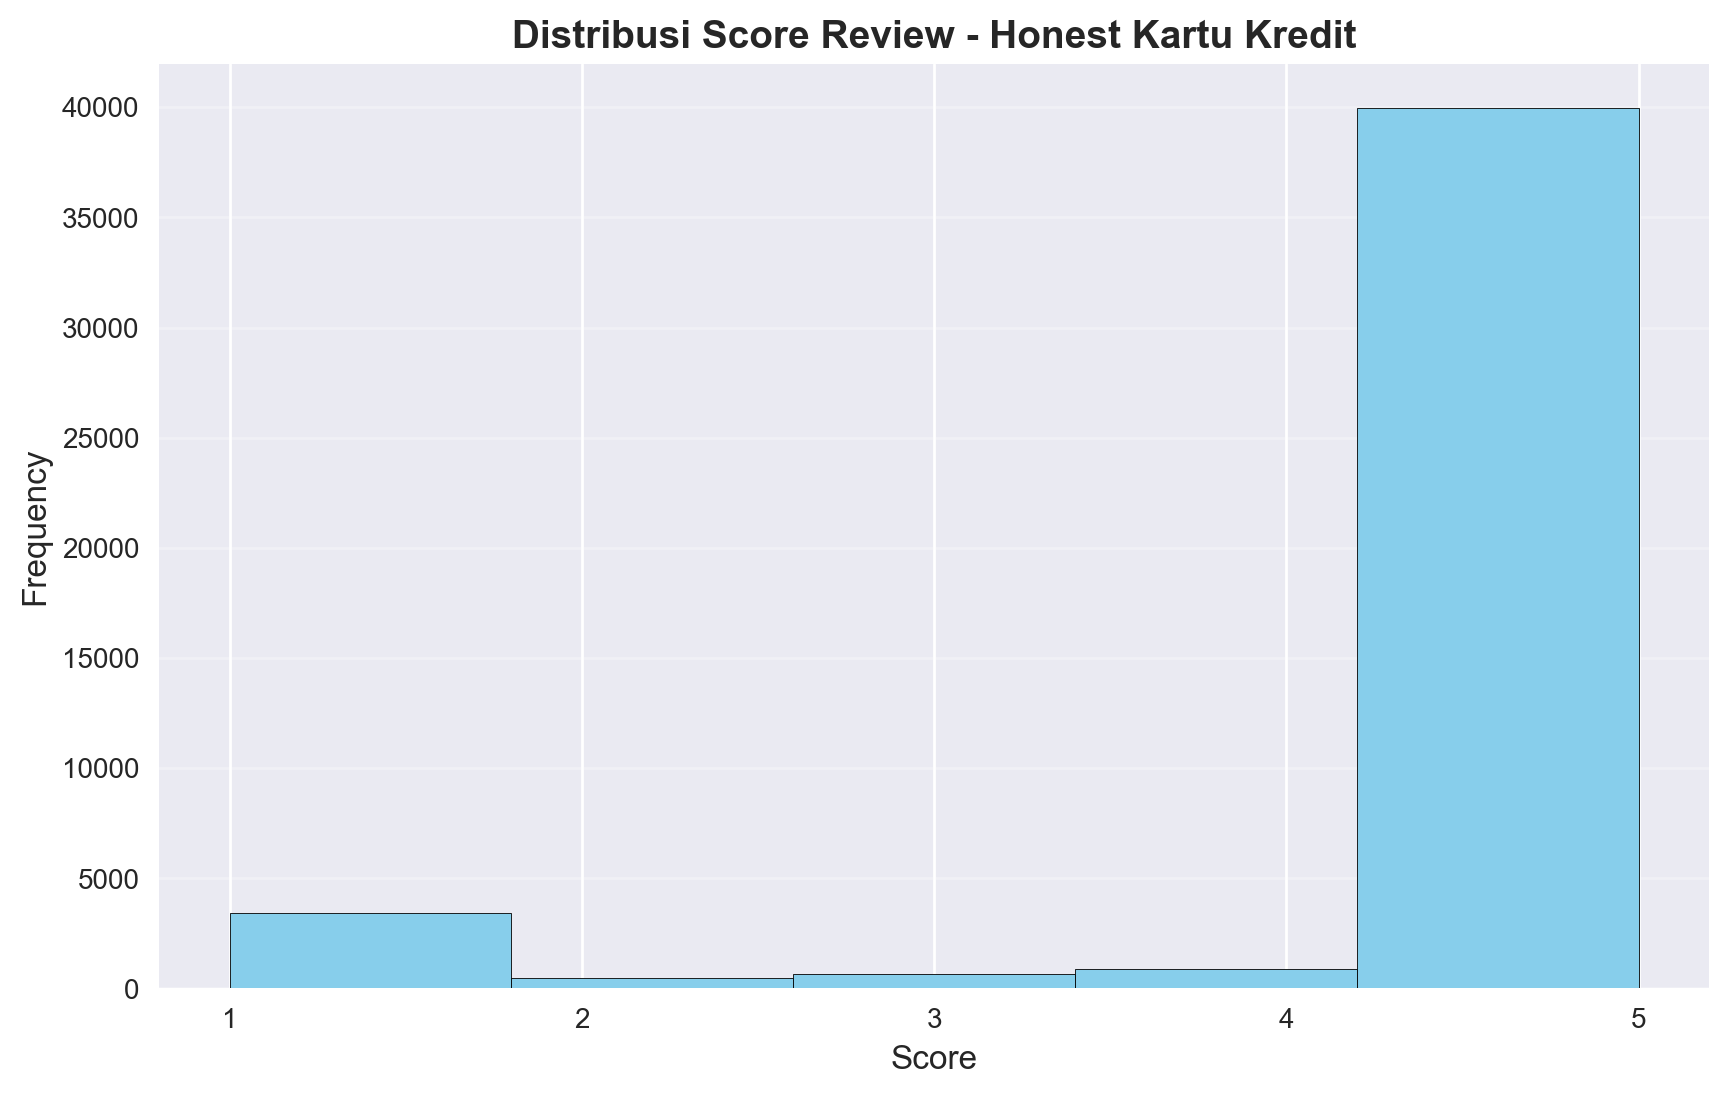

In [12]:
# Check distribution of review scores
print("⭐ Distribusi Score Review:")
print(df_honest['score'].value_counts().sort_index())

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df_honest['score'], bins=5, edgecolor='black', color='skyblue')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribusi Score Review - Honest Kartu Kredit', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)
plt.show()

## 🧹 Data Preprocessing

### Step 1: Lowercase Conversion
Mengubah semua teks menjadi lowercase untuk konsistensi.

In [15]:
# Change the reviews type to string
df_honest['content'] = df_honest['content'].astype(str)

# Save original content for comparison
df_honest['content_original'] = df_honest['content'].copy()

# Before lowercasing - check if there are any uppercase letters
has_upper = df_honest['content'].str.contains(r'[A-Z]').sum()
print(f"📊 Reviews with uppercase letters: {has_upper} dari {len(df_honest)}")

if has_upper > 0:
    # Find first review with uppercase
    idx = df_honest[df_honest['content'].str.contains(r'[A-Z]')].index[0]
    print(f"\n📝 BEFORE Lowercasing (index {idx}):")
    print(df_honest['content'][idx])
else:
    print("\n📝 BEFORE Lowercasing (sample):")
    print(df_honest['content'][0])

# Lowercase all reviews
df_honest['content'] = df_honest['content'].apply(lambda x: x.lower())

if has_upper > 0:
    print(f"\n📝 AFTER Lowercasing (index {idx}):")
    print(df_honest['content'][idx])
else:
    print("\n📝 AFTER Lowercasing (sample):")
    print(df_honest['content'][0])
    print("\nℹ️ Note: Data review sudah dalam lowercase semua")

📊 Reviews with uppercase letters: 0 dari 45376

📝 BEFORE Lowercasing (sample):
terimakasih atas selesnya ramah baik #rio

📝 AFTER Lowercasing (sample):
terimakasih atas selesnya ramah baik #rio

ℹ️ Note: Data review sudah dalam lowercase semua


## 📊 Text Statistics

Menghitung statistik teks:
- **Word Count**: Jumlah kata
- **Uppercase Char Count**: Jumlah huruf kapital (sebelum lowercasing)
- **Special Char Count**: Jumlah karakter spesial (tanda baca)

In [16]:
import string

df_honest['wordCount'] = [len(review.split()) for review in df_honest['content']]

# Use original content to count uppercase (before lowercasing)
df_honest['uppercaseCharCount'] = [sum(char.isupper() for char in review) 
                                     for review in df_honest['content_original']]

df_honest['specialCharCount'] = [sum(char in string.punctuation for char in review) 
                                   for review in df_honest['content']]

print("✅ Text statistics calculated!")
print(f"Total uppercase characters found: {df_honest['uppercaseCharCount'].sum()}")
df_honest.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective", 
                   "wordCount", "uppercaseCharCount", "specialCharCount"]]

✅ Text statistics calculated!
Total uppercase characters found: 24


,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,terimakasih atas selesnya ramah baik #rio,5,0.000000,0.000000,6,0,1
1,baik,5,0.000000,0.000000,1,0,0
2,mantep,5,0.000000,0.000000,1,0,0
3,terima kasih,5,0.000000,0.000000,2,0,0
4,"pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan diarahkan, recommended bangett. buruan yang lain ajuin",5,0.000000,0.000000,24,0,3
...,...,...,...,...,...,...,...
45371,"keren banget aplikasinya! semua proses pengajuan cepat dan ga perlu ribet, yang paling penting ga perlu nunggu lama untuk tau di approve atau gak. the next super app!",5,0.208333,0.333333,28,0,4
45372,beru kali ini nemu proses kartu kredit secepat ini. cuma beberapa menit langsung disetujui dan langsung bisa dipakai bayar transaksi di e-commerce. mantap lah,5,0.000000,0.000000,24,0,3
45373,"suka banget sama aplikasi ini, mudah mengajukan hanya via hp. gak ribet dan fleksible dalam menggunakannya. tinggal scan, tap tap, bayar.",5,0.000000,0.000000,21,0,6
45374,"akhirnya ada juga aplikasi kartu kredit di indonesia!! proses pengajuan cepat dan mudah, aplikasinya pun simple dan mudah dimengerti.",5,0.000000,0.357143,19,0,4


## 🏷️ Sentiment Rating Classification

Mengklasifikasikan sentiment berdasarkan score:
- **Score > 3**: Positive ✅
- **Score = 3**: Neutral 😐
- **Score < 3**: Negative ❌

In [17]:
# Add sentiment_rating column based on score
df_honest['sentiment_rating'] = df_honest['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)

print("✅ Sentiment rating classification completed!")
print("\n📊 Distribution:")
print(df_honest['sentiment_rating'].value_counts())

df_honest.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective", "sentiment_rating"]]

✅ Sentiment rating classification completed!

📊 Distribution:
sentiment_rating
Positive    40825
Negative     3916
Neutral       635
Name: count, dtype: int64


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,terimakasih atas selesnya ramah baik #rio,5,0.000000,0.000000,Positive
1,baik,5,0.000000,0.000000,Positive
2,mantep,5,0.000000,0.000000,Positive
3,terima kasih,5,0.000000,0.000000,Positive
4,"pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan diarahkan, recommended bangett. buruan yang lain ajuin",5,0.000000,0.000000,Positive
...,...,...,...,...,...
45371,"keren banget aplikasinya! semua proses pengajuan cepat dan ga perlu ribet, yang paling penting ga perlu nunggu lama untuk tau di approve atau gak. the next super app!",5,0.208333,0.333333,Positive
45372,beru kali ini nemu proses kartu kredit secepat ini. cuma beberapa menit langsung disetujui dan langsung bisa dipakai bayar transaksi di e-commerce. mantap lah,5,0.000000,0.000000,Positive
45373,"suka banget sama aplikasi ini, mudah mengajukan hanya via hp. gak ribet dan fleksible dalam menggunakannya. tinggal scan, tap tap, bayar.",5,0.000000,0.000000,Positive
45374,"akhirnya ada juga aplikasi kartu kredit di indonesia!! proses pengajuan cepat dan mudah, aplikasinya pun simple dan mudah dimengerti.",5,0.000000,0.357143,Positive


## 📈 Sentiment Scatter Plot

Visualisasi hubungan antara **Polarity** dan **Subjectivity** dengan warna berdasarkan **Sentiment Rating**.

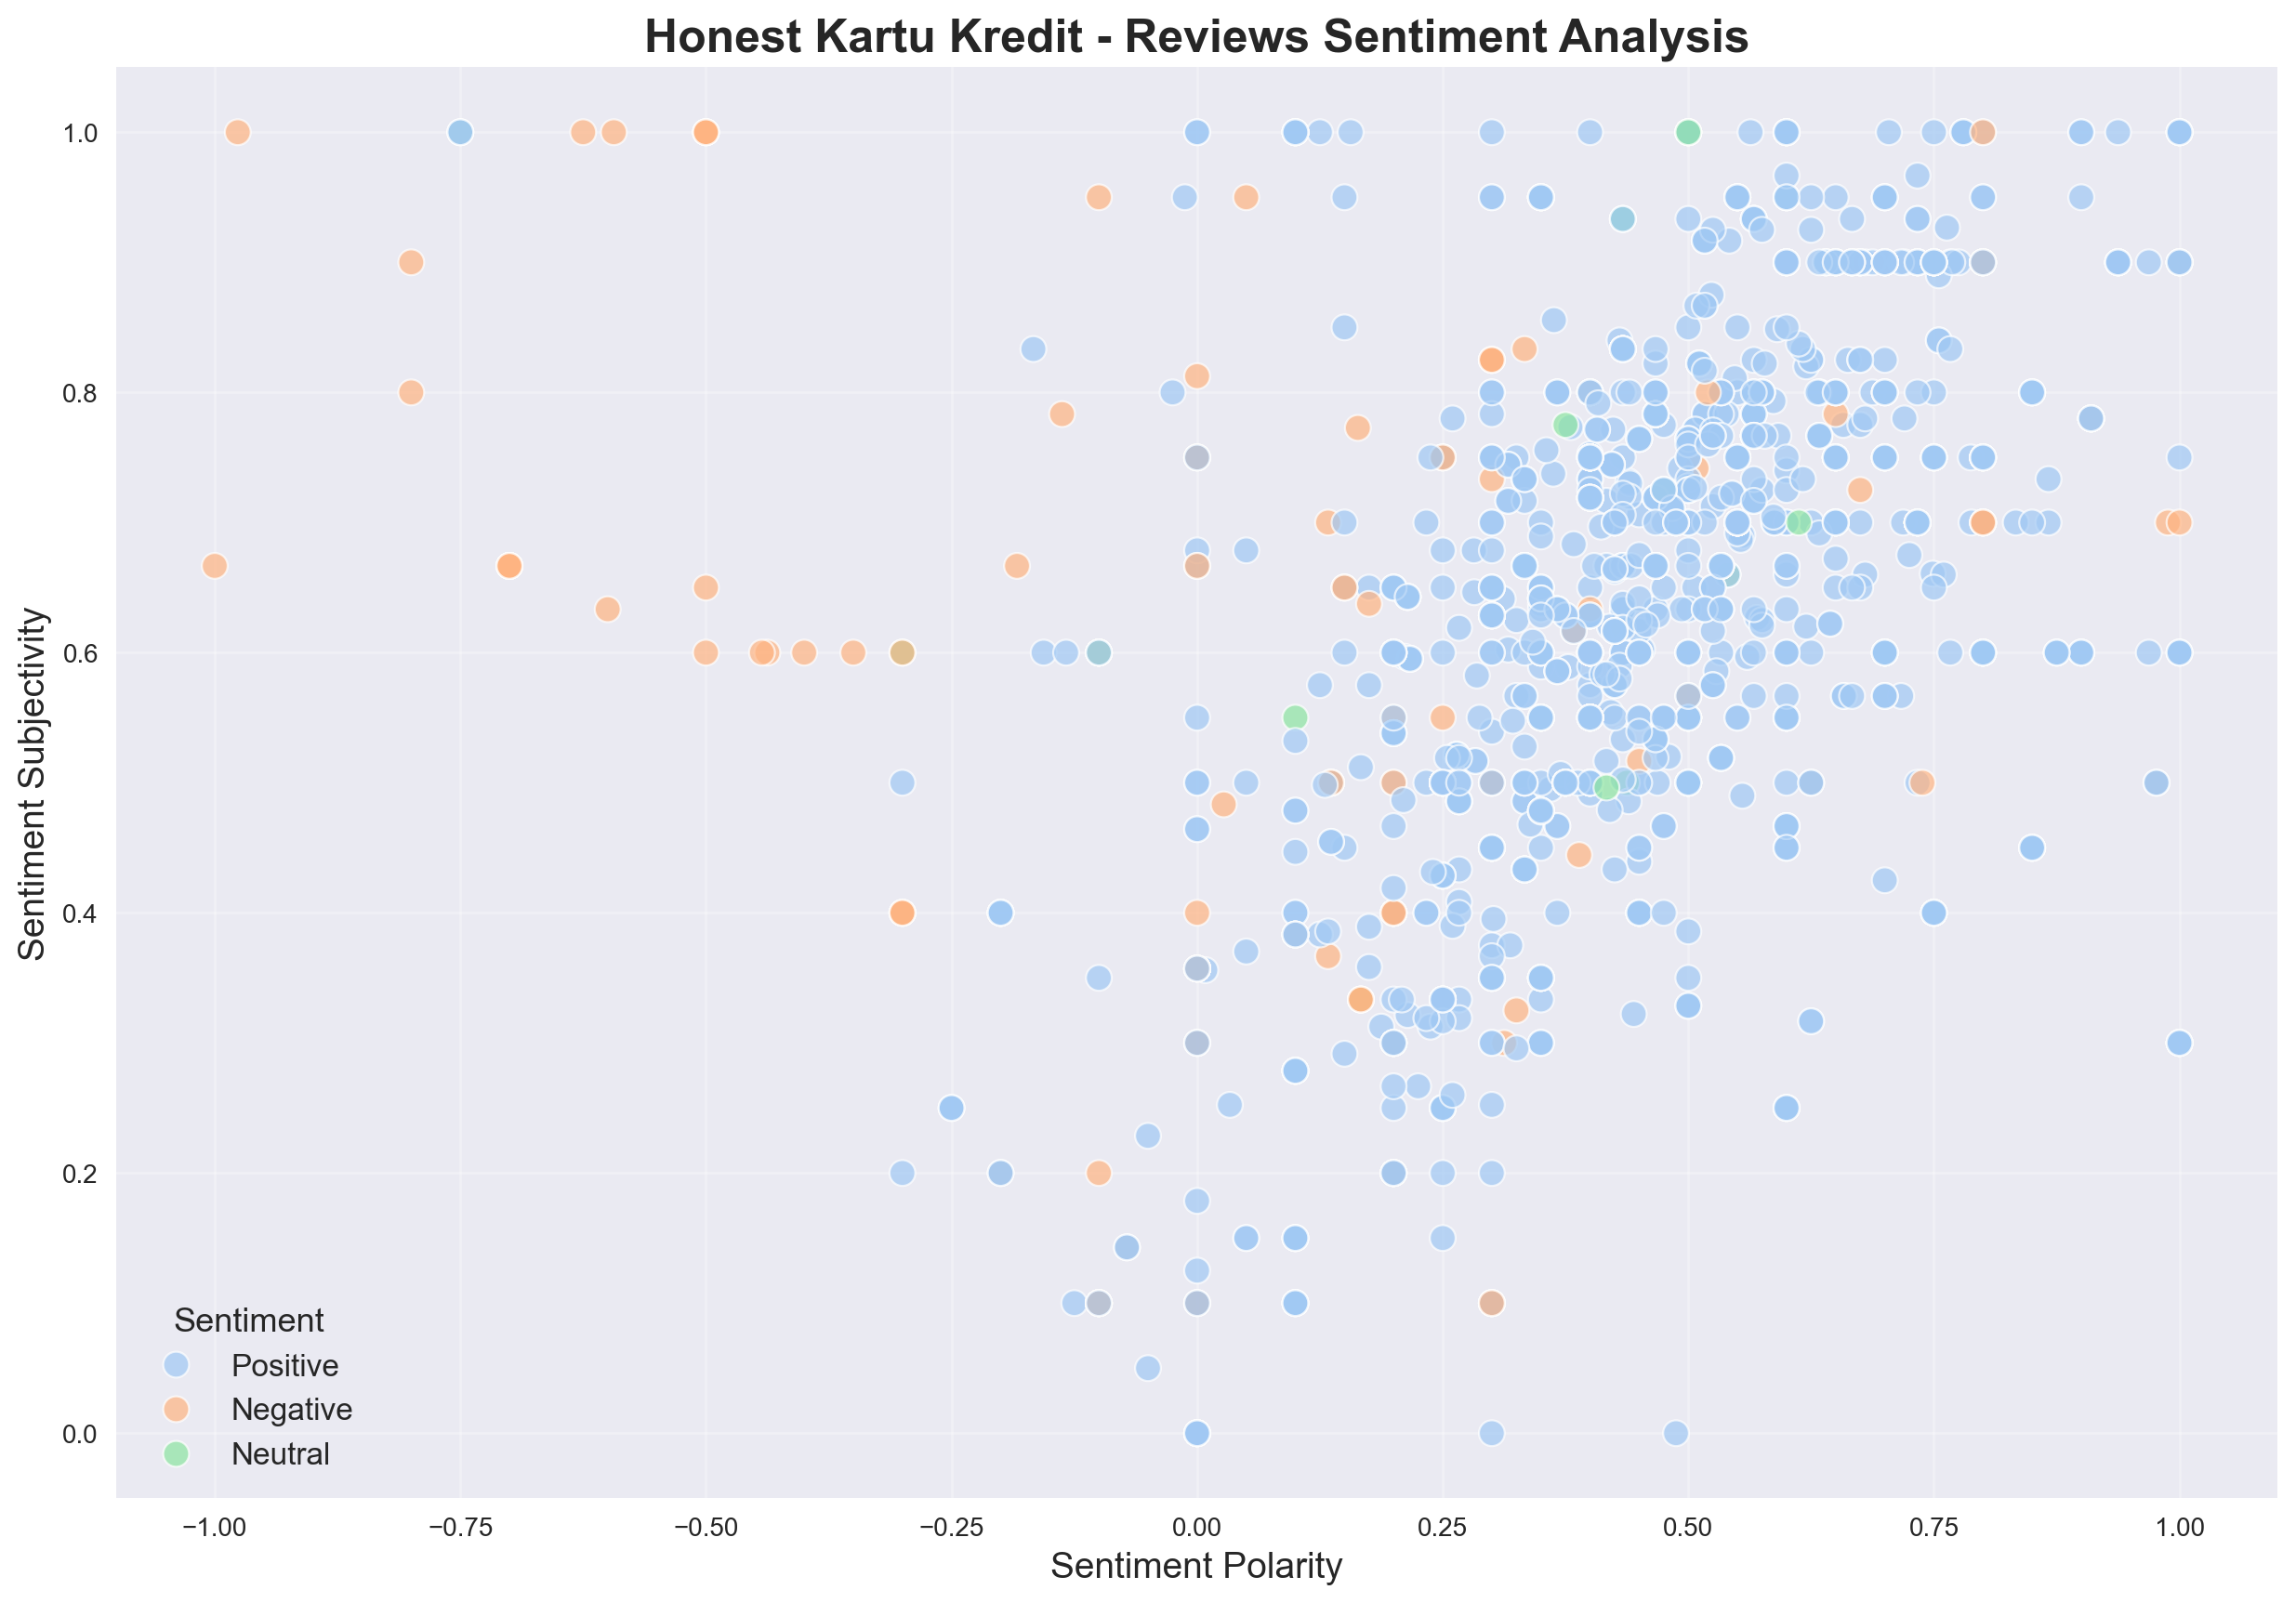

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_honest['sentiment_polarity'], 
                y=df_honest['sentiment_subjective'],
                hue=df_honest['sentiment_rating'], 
                edgecolor='white', 
                palette="pastel",
                s=100,
                alpha=0.7)
plt.xlabel('Sentiment Polarity', fontsize=14)
plt.ylabel('Sentiment Subjectivity', fontsize=14)
plt.title("Honest Kartu Kredit - Reviews Sentiment Analysis", fontsize=18, fontweight='bold')
plt.legend(title='Sentiment', fontsize=12, title_fontsize=13)
plt.grid(alpha=0.3)
plt.show()

## 💾 Export: Before Stopwords Removal

Simpan data sebelum menghapus stopwords.

In [19]:
# Save DataFrame before stopwords removal
filename_before = 'df_honest_before_stopwords.csv'
df_honest.to_csv(filename_before, index=False)
print(f"✅ Data saved to: {filename_before}")

✅ Data saved to: df_honest_before_stopwords.csv


## 🛑 Download NLTK Stopwords

Download daftar stopwords dari NLTK untuk bahasa Indonesia dan Inggris.

In [20]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Indonesian stopwords + custom additions
stop = stopwords.words('indonesian') + stopwords.words('english') + [
    "someone", "still", "would", "need", "app", "aplikasi", "nya", "sih", "yg", "ga"
]

print(f"📋 Total stopwords: {len(stop)}")
print(f"\n👁️ Preview stopwords:")
print(stop[:20])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mikba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


📋 Total stopwords: 966

👁️ Preview stopwords:
['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


## 🧹 Stopwords Removal

Menghapus stopwords dari review untuk fokus pada kata-kata penting.

In [21]:
import nltk
from nltk import FreqDist

# Create copy for stopwords processing
df_honest_stopwords = df_honest.loc[:, ["content", "score", "sentiment_polarity", 
                                         "sentiment_subjective", "sentiment_rating"]].copy()

print("🔄 Removing stopwords...")

# Exclude stopwords using regex
pat = r'\b(?:{})\b'.format('|'.join(stop))
df_honest_stopwords['tweet_without_stopwords'] = df_honest_stopwords['content'].str.replace(pat, '', regex=True)
df_honest_stopwords['tweet_without_stopwords'] = df_honest_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ', regex=True)

print("✅ Stopwords removed!")
print(df_honest_stopwords.head())

🔄 Removing stopwords...
✅ Stopwords removed!
                                                                                                                                                              content  \
0                                                                                                                           terimakasih atas selesnya ramah baik #rio   
1                                                                                                                                                                baik   
2                                                                                                                                                              mantep   
3                                                                                                                                                        terima kasih   
4  pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan

## 📊 Word Count Comparison

Membandingkan jumlah kata sebelum dan sesudah stopwords removal.

In [22]:
# Count words before and after stopwords removal
df_honest_stopwords['wordCount'] = [len(review.split()) for review in df_honest_stopwords['content']]
df_honest_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_honest_stopwords['tweet_without_stopwords']]

print("📊 Word Count Statistics:")
print(f"Average words BEFORE stopwords: {df_honest_stopwords['wordCount'].mean():.2f}")
print(f"Average words AFTER stopwords: {df_honest_stopwords['wordCount_after_stopwords'].mean():.2f}")
print(f"Reduction: {((df_honest_stopwords['wordCount'].mean() - df_honest_stopwords['wordCount_after_stopwords'].mean()) / df_honest_stopwords['wordCount'].mean() * 100):.1f}%")

df_honest_stopwords.loc[:, ["content", "score", "sentiment_rating", "wordCount", 
                             "tweet_without_stopwords", "wordCount_after_stopwords"]]

📊 Word Count Statistics:
Average words BEFORE stopwords: 12.15
Average words AFTER stopwords: 7.98
Reduction: 34.3%


,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,terimakasih atas selesnya ramah baik #rio,5,Positive,6,terimakasih selesnya ramah #rio,4
1,baik,5,Positive,1,,0
2,mantep,5,Positive,1,mantep,1
3,terima kasih,5,Positive,2,terima kasih,2
4,"pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan diarahkan, recommended bangett. buruan yang lain ajuin",5,Positive,24,"pengajuan cepat dibanti banget kak yosep customer care . dibimbing diarahkan, recommended bangett. buruan ajuin",15
...,...,...,...,...,...,...
45371,"keren banget aplikasinya! semua proses pengajuan cepat dan ga perlu ribet, yang paling penting ga perlu nunggu lama untuk tau di approve atau gak. the next super app!",5,Positive,28,"keren banget aplikasinya! proses pengajuan cepat ribet, nunggu tau approve gak. next super !",14
45372,beru kali ini nemu proses kartu kredit secepat ini. cuma beberapa menit langsung disetujui dan langsung bisa dipakai bayar transaksi di e-commerce. mantap lah,5,Positive,24,beru kali nemu proses kartu kredit secepat . menit langsung disetujui langsung dipakai bayar transaksi e-commerce. mantap,17
45373,"suka banget sama aplikasi ini, mudah mengajukan hanya via hp. gak ribet dan fleksible dalam menggunakannya. tinggal scan, tap tap, bayar.",5,Positive,21,"suka banget , mudah mengajukan via hp. gak ribet fleksible menggunakannya. tinggal scan, tap tap, bayar.",16
45374,"akhirnya ada juga aplikasi kartu kredit di indonesia!! proses pengajuan cepat dan mudah, aplikasinya pun simple dan mudah dimengerti.",5,Positive,19,"kartu kredit indonesia!! proses pengajuan cepat mudah, aplikasinya simple mudah dimengerti.",11


## 📊 Most Frequent Words Analysis

Visualisasi kata-kata yang paling sering muncul setelah stopwords removal.

📊 Analyzing most frequent words...


C:\Users\mikba\AppData\Local\Temp\ipykernel_10940\3288837235.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="viridis")


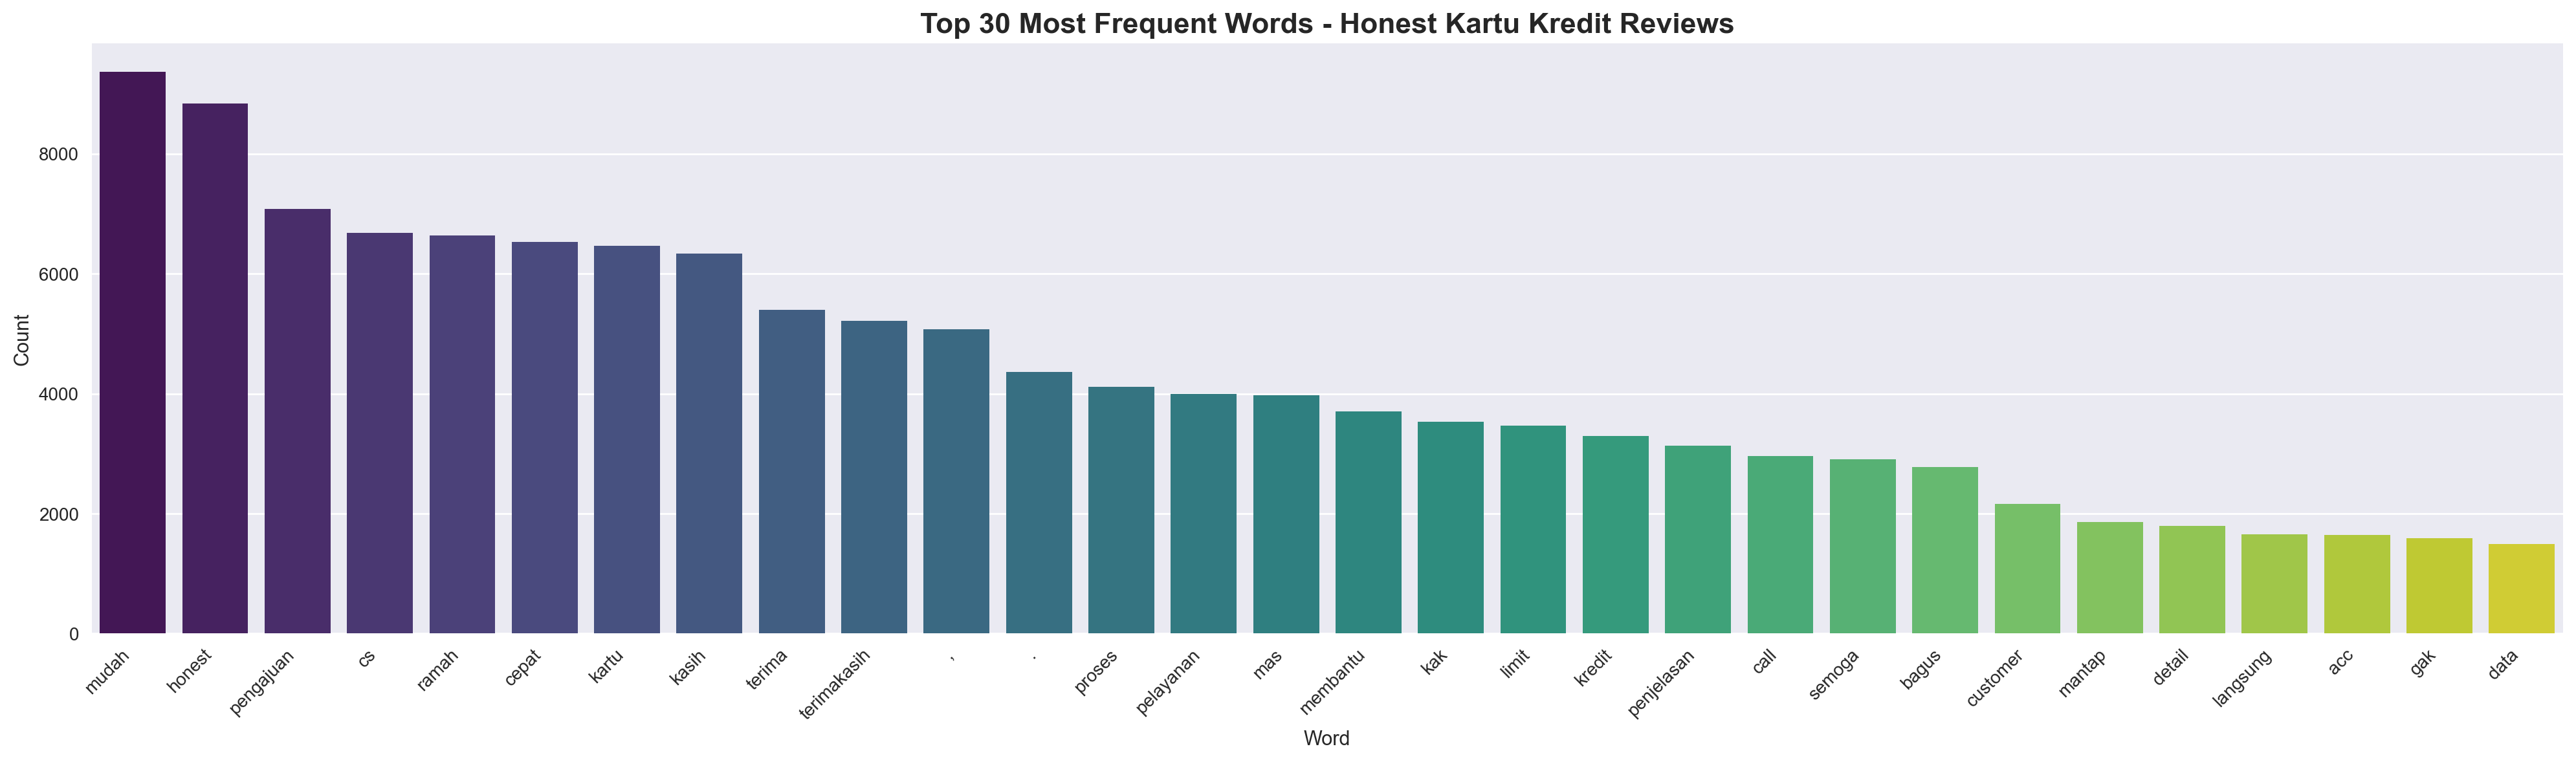

In [23]:
# Function to plot most frequent terms
def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()
    
    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    
    # Selecting top N most frequent words
    d = words_df.nlargest(columns="count", n=terms)
    
    plt.figure(figsize=(20, 6))
    ax = sns.barplot(data=d, x="word", y="count", palette="viridis")
    ax.set(ylabel='Count', xlabel='Word')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {terms} Most Frequent Words - Honest Kartu Kredit Reviews', 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("📊 Analyzing most frequent words...")
freq_words(df_honest_stopwords['tweet_without_stopwords'], terms=30)

## 🔧 Stemming (Optional)

Mengubah kata ke bentuk dasar (root form).
Contoh: "berlari", "lari", "pelari" → "lari"

In [24]:
# Stemming function
from nltk.stem import PorterStemmer

def stemming(x):
    st = PorterStemmer()
    if x is not None:
        stemmed_words = []
        for word in x.split():
            stemmed_words.append(st.stem(word))
        return ' '.join(stemmed_words)
    return x

# Apply stemming (optional - uncomment to use)
# df_honest_stopwords['tweet_stemmed'] = df_honest_stopwords['tweet_without_stopwords'].apply(lambda x: stemming(x))

print("ℹ️ Stemming function defined (optional step)")

ℹ️ Stemming function defined (optional step)


## 🧹 Drop Missing Values

Menghapus baris yang memiliki nilai kosong (NA/NaN).

In [25]:
# Drop NA values
before_count = len(df_honest_stopwords)
df_honest_stopwords.dropna(inplace=True)
after_count = len(df_honest_stopwords)

print(f"📊 Data Cleaning Summary:")
print(f"Rows before: {before_count}")
print(f"Rows after: {after_count}")
print(f"Rows dropped: {before_count - after_count}")

df_honest_stopwords.info()

📊 Data Cleaning Summary:
Rows before: 45376
Rows after: 45376
Rows dropped: 0
<class 'pandas.DataFrame'>
RangeIndex: 45376 entries, 0 to 45375
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    45376 non-null  str    
 1   score                      45376 non-null  int64  
 2   sentiment_polarity         45376 non-null  float64
 3   sentiment_subjective       45376 non-null  float64
 4   sentiment_rating           45376 non-null  str    
 5   tweet_without_stopwords    45376 non-null  str    
 6   wordCount                  45376 non-null  int64  
 7   wordCount_after_stopwords  45376 non-null  int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 8.9 MB


## 💾 Export: After Stopwords Removal

Simpan data final setelah preprocessing.

In [26]:
# Save processed data to CSV
filename_after = 'df_honest_after_stopwords.csv'
df_honest_stopwords.to_csv(filename_after, index=False)

print(f"✅ Final data saved to: {filename_after}")
print(f"📊 Total rows: {len(df_honest_stopwords)}")
print(f"📋 Columns: {', '.join(df_honest_stopwords.columns)}")

✅ Final data saved to: df_honest_after_stopwords.csv
📊 Total rows: 45376
📋 Columns: content, score, sentiment_polarity, sentiment_subjective, sentiment_rating, tweet_without_stopwords, wordCount, wordCount_after_stopwords


## 👁️ Final Preview

Preview data final yang sudah melalui semua preprocessing steps.

In [27]:
# Display final processed data
print("📊 FINAL PROCESSED DATA:")
df_honest_stopwords.loc[:, ["content", "score", "sentiment_rating", "wordCount", 
                             "tweet_without_stopwords", "wordCount_after_stopwords"]]

📊 FINAL PROCESSED DATA:


,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,terimakasih atas selesnya ramah baik #rio,5,Positive,6,terimakasih selesnya ramah #rio,4
1,baik,5,Positive,1,,0
2,mantep,5,Positive,1,mantep,1
3,terima kasih,5,Positive,2,terima kasih,2
4,"pengajuan nya cepat dan sangat dibanti banget dengan kak yosep dari customer care nya. sangat dibimbing dan diarahkan, recommended bangett. buruan yang lain ajuin",5,Positive,24,"pengajuan cepat dibanti banget kak yosep customer care . dibimbing diarahkan, recommended bangett. buruan ajuin",15
...,...,...,...,...,...,...
45371,"keren banget aplikasinya! semua proses pengajuan cepat dan ga perlu ribet, yang paling penting ga perlu nunggu lama untuk tau di approve atau gak. the next super app!",5,Positive,28,"keren banget aplikasinya! proses pengajuan cepat ribet, nunggu tau approve gak. next super !",14
45372,beru kali ini nemu proses kartu kredit secepat ini. cuma beberapa menit langsung disetujui dan langsung bisa dipakai bayar transaksi di e-commerce. mantap lah,5,Positive,24,beru kali nemu proses kartu kredit secepat . menit langsung disetujui langsung dipakai bayar transaksi e-commerce. mantap,17
45373,"suka banget sama aplikasi ini, mudah mengajukan hanya via hp. gak ribet dan fleksible dalam menggunakannya. tinggal scan, tap tap, bayar.",5,Positive,21,"suka banget , mudah mengajukan via hp. gak ribet fleksible menggunakannya. tinggal scan, tap tap, bayar.",16
45374,"akhirnya ada juga aplikasi kartu kredit di indonesia!! proses pengajuan cepat dan mudah, aplikasinya pun simple dan mudah dimengerti.",5,Positive,19,"kartu kredit indonesia!! proses pengajuan cepat mudah, aplikasinya simple mudah dimengerti.",11


---

## ✅ Summary Pipeline

### Proses yang Telah Dilakukan:
1. ✅ **Scraping** review aplikasi Honest dari Google Play Store
2. ✅ **Sentiment Analysis** dengan TextBlob (polarity & subjectivity)
3. ✅ **Data Preprocessing**:
   - Lowercase conversion
   - Text statistics (word count, special chars)
   - Sentiment rating classification
4. ✅ **Stopwords Removal** (Indonesian + English)
5. ✅ **Visualization**:
   - Score distribution histogram
   - Sentiment scatter plot
   - Most frequent words bar chart
6. ✅ **Export** ke CSV files:
   - `df_honest_reviews.csv` (raw data)
   - `df_honest_before_stopwords.csv` (sebelum stopwords)
   - `df_honest_after_stopwords.csv` (final processed)

### Next Steps:
- 🤖 **Machine Learning**: Train model untuk sentiment classification
- 📊 **Advanced Analysis**: Topic modeling, word clouds
- 📈 **Time Series**: Analisis trend sentiment dari waktu ke waktu
- 🔍 **Deep Dive**: Analisis review spesifik per rating/version

---

**© 2026 | PBA Project - Honest Kartu Kredit App Review Analysis**